# 02 — Yield Curve Construction & Interpolation

**Fixed Income Analytics** | Palma, R. (2026)

This notebook builds the U.S. Treasury yield curve from
real FRED data using three methods: linear interpolation,
cubic spline and Nelson-Siegel-Svensson calibration.

### Contents
1. Loading real Treasury data from FRED
2. Bootstrapping the discount curve
3. Comparing interpolation methods
4. Interactive NSS parameter explorer
5. Historical yield curve viewer
6. Forward curve analysis

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import RdYlGn
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed
from IPython.display import display
import warnings
warnings.filterwarnings("ignore")

sys.path.append("..")
from src.curves import DiscountCurve, Bootstrapper, CurveInterpolator

# ── Plot style ────────────────────────────────────────────────
plt.rcParams.update({
    "figure.figsize":    (12, 5),
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "serif",
    "axes.prop_cycle":   plt.cycler(color=[
        "#2E75B6", "#C00000", "#70AD47",
        "#ED7D31", "#7030A0"
    ])
})

print("✓ Imports OK")

✓ Imports OK


---
## 1. Loading Real Treasury Data from FRED

We load U.S. Treasury constant maturity yields directly
from the Federal Reserve (FRED). These are the yields
Murex MX.3 would use as market inputs.

In [2]:
import os
from dotenv import load_dotenv
load_dotenv("../.env")

try:
    from fredapi import Fred
    fred = Fred(api_key=os.getenv("FRED_API_KEY"))

    # Treasury constant maturity yields
    tickers = {
        0.25:  "DTB3",     # 3-month
        0.5:   "DTB6",     # 6-month
        1:     "DGS1",     # 1-year
        2:     "DGS2",     # 2-year
        3:     "DGS3",     # 3-year
        5:     "DGS5",     # 5-year
        7:     "DGS7",     # 7-year
        10:    "DGS10",    # 10-year
        20:    "DGS20",    # 20-year
        30:    "DGS30",    # 30-year
    }

    # Download all series
    raw = {mat: fred.get_series(ticker) / 100
           for mat, ticker in tickers.items()}

    df_yields = pd.DataFrame(raw).dropna()
    df_yields.index = pd.to_datetime(df_yields.index)
    df_yields = df_yields.sort_index()

    print(f"✓ Data loaded: {len(df_yields)} trading days")
    print(f"  From: {df_yields.index[0].date()}")
    print(f"  To:   {df_yields.index[-1].date()}")
    print(f"  Maturities: {list(df_yields.columns)}")

except Exception as e:
    print(f"FRED unavailable ({e})")
    print("Using synthetic data for demonstration...")

    # Synthetic fallback — normal upward sloping curve
    mats  = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30])
    dates = pd.date_range("2020-01-01", "2025-01-01", freq="B")
    np.random.seed(42)
    base  = np.array([0.02, 0.022, 0.025, 0.028,
                      0.030, 0.033, 0.035, 0.037,
                      0.040, 0.042])
    noise = np.random.randn(len(dates), len(mats)) * 0.002
    df_yields = pd.DataFrame(
        base + noise.cumsum(axis=0) * 0.01,
        index=dates, columns=mats
    ).clip(lower=0.001)

print(f"\nLatest yields (most recent date):")
print(df_yields.iloc[-1].to_string())

FRED unavailable (No module named 'fredapi')
Using synthetic data for demonstration...

Latest yields (most recent date):
0.25     0.020485
0.50     0.022510
1.00     0.023721
2.00     0.027026
3.00     0.030293
5.00     0.032423
7.00     0.035162
10.00    0.036709
20.00    0.039657
30.00    0.042915


---
## 2. Building the Discount Curve

We convert observed yields to continuously compounded
rates and build a DiscountCurve object.

$$r_c = \ln(1 + r_d)$$

In [3]:
# Use the most recent date
latest_date   = df_yields.index[-1]
latest_yields = df_yields.loc[latest_date].values
maturities    = np.array(df_yields.columns, dtype=float)

# Build curve via Bootstrapper
curve = Bootstrapper.from_yields(maturities, latest_yields)

print(f"Curve date: {latest_date.date()}")
print(f"\n{'Maturity':>10} {'Yield':>10} {'Spot (cont)':>12} {'Z(t)':>10}")
print("-" * 46)
for t, y, r, z in zip(maturities,
                       latest_yields,
                       curve.spot_rates,
                       curve.discount_factors()):
    print(f"{t:>10.2f} {y:>10.2%} {r:>12.4%} {z:>10.6f}")

Curve date: 2025-01-01

  Maturity      Yield  Spot (cont)       Z(t)
----------------------------------------------
      0.25      2.05%      2.0278%   0.994943
      0.50      2.25%      2.2261%   0.988931
      1.00      2.37%      2.3444%   0.976829
      2.00      2.70%      2.6667%   0.948063
      3.00      3.03%      2.9844%   0.914360
      5.00      3.24%      3.1908%   0.852534
      7.00      3.52%      3.4557%   0.785133
     10.00      3.67%      3.6051%   0.697319
     20.00      3.97%      3.8891%   0.459411
     30.00      4.29%      4.2019%   0.283488


---
## 3. Comparing Interpolation Methods

Three methods on the same observed data:

| Method | Forwards | Structure |
|--------|----------|-----------|
| Linear | Discontinuous | None |
| Cubic Spline | Continuous | None |
| NSS | Continuous | Economic |

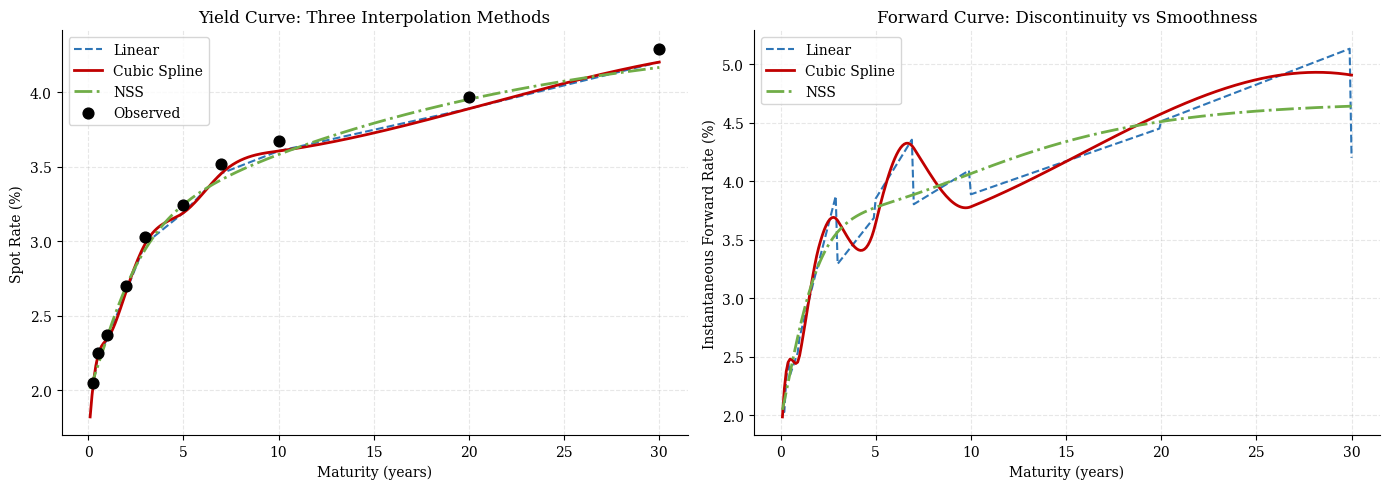


NSS Parameters:
  Long-run level  (b0): 4.6766%
  Short-run adj   (b1): -2.7020%
  Curvature 1     (b2): -1.5584%
  Curvature 2     (b3): -2.2504%
  Decay 1         (l1): 100.1054%
  Decay 2         (l2): 500.0084%
  Short rate lim  (b0+b1): 1.9746%
  Long rate lim   (b0): 4.6766%


In [4]:
interp  = CurveInterpolator(curve)
beta    = interp.fit_nss()
t_grid  = np.linspace(0.1, 30, 300)
results = interp.compare(t_grid, beta)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Spot curves ─────────────────────────────────────────
ax = axes[0]
ax.plot(t_grid, results["linear"]       * 100,
        label="Linear",       lw=1.5, ls="--")
ax.plot(t_grid, results["cubic_spline"] * 100,
        label="Cubic Spline", lw=2)
ax.plot(t_grid, results["nss"]          * 100,
        label="NSS",          lw=2,   ls="-.")
ax.scatter(maturities, latest_yields * 100,
           color="black", zorder=5, s=60,
           label="Observed", marker="o")
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Spot Rate (%)")
ax.set_title("Yield Curve: Three Interpolation Methods")
ax.legend()

# ── Right: Forward curves ─────────────────────────────────────
ax = axes[1]
ax.plot(t_grid, results["forward_linear"] * 100,
        label="Linear",       lw=1.5, ls="--")
ax.plot(t_grid, results["forward_spline"] * 100,
        label="Cubic Spline", lw=2)
ax.plot(t_grid, results["forward_nss"]    * 100,
        label="NSS",          lw=2,   ls="-.")
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Instantaneous Forward Rate (%)")
ax.set_title("Forward Curve: Discontinuity vs Smoothness")
ax.legend()

plt.tight_layout()
plt.savefig("../figures/02_interpolation_comparison.png",
            dpi=150)
plt.show()

print("\nNSS Parameters:")
for k, v in interp.nss_summary(beta).items():
    print(f"  {k}: {v:.4%}")

---
## 4. Interactive NSS Parameter Explorer

Each parameter has a direct economic interpretation:

| Parameter | Name | Effect |
|-----------|------|--------|
| $\beta_0$ | Level | Parallel shift of entire curve |
| $\beta_1$ | Slope | Steepening / flattening |
| $\beta_2$ | Curvature 1 | Medium-term hump |
| $\beta_3$ | Curvature 2 | Second hump (Svensson) |
| $\lambda_1$ | Decay 1 | Location of first hump |
| $\lambda_2$ | Decay 2 | Location of second hump |

Use the sliders to explore how each parameter
deforms the spot and forward curves.

In [5]:
def plot_nss_explorer(b0, b1, b2, b3, l1, l2):
    """Interactive NSS parameter explorer."""
    beta   = np.array([b0, b1, b2, b3, l1, l2])
    t_grid = np.linspace(0.1, 30, 300)

    r_spot    = CurveInterpolator.nss_spot(t_grid, beta)
    r_forward = CurveInterpolator.nss_forward(t_grid, beta)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Spot curve ────────────────────────────────────────────
    ax = axes[0]
    ax.plot(t_grid, r_spot * 100,
            color="#2E75B6", lw=2.5)
    ax.scatter(maturities, latest_yields * 100,
               color="black", zorder=5, s=60,
               marker="o", label="Observed")
    ax.axhline(b0 * 100, color="gray", ls=":",
               lw=1, label=f"Long-run level β₀={b0:.2%}")
    ax.axhline((b0 + b1) * 100, color="tomato",
               ls=":", lw=1,
               label=f"Short-run β₀+β₁={(b0+b1):.2%}")
    ax.set_xlim(0, 30)
    ax.set_ylim(-1, 10)
    ax.set_xlabel("Maturity (years)")
    ax.set_ylabel("Spot Rate (%)")
    ax.set_title("NSS Spot Curve")
    ax.legend(fontsize=9)

    # ── Forward curve ─────────────────────────────────────────
    ax = axes[1]
    ax.plot(t_grid, r_forward * 100,
            color="#C00000", lw=2.5)
    ax.axhline(b0 * 100, color="gray", ls=":",
               lw=1, label=f"Long-run β₀={b0:.2%}")
    ax.set_xlim(0, 30)
    ax.set_ylim(-1, 10)
    ax.set_xlabel("Maturity (years)")
    ax.set_ylabel("Instantaneous Forward Rate (%)")
    ax.set_title("NSS Forward Curve")
    ax.legend(fontsize=9)

    # ── Title with current params ─────────────────────────────
    fig.suptitle(
        f"β₀={b0:.3f}  β₁={b1:.3f}  "
        f"β₂={b2:.3f}  β₃={b3:.3f}  "
        f"λ₁={l1:.2f}  λ₂={l2:.2f}",
        fontsize=10, y=1.01
    )

    plt.tight_layout()
    plt.show()

# ── Widget definitions ────────────────────────────────────────
style  = {"description_width": "120px"}
layout = widgets.Layout(width="500px")

b0_slider = widgets.FloatSlider(
    value=0.04, min=0.005, max=0.10, step=0.001,
    description="β₀ (Level):",
    style=style, layout=layout,
    readout_format=".3f"
)
b1_slider = widgets.FloatSlider(
    value=-0.02, min=-0.05, max=0.05, step=0.001,
    description="β₁ (Slope):",
    style=style, layout=layout,
    readout_format=".3f"
)
b2_slider = widgets.FloatSlider(
    value=0.01, min=-0.05, max=0.05, step=0.001,
    description="β₂ (Curvature 1):",
    style=style, layout=layout,
    readout_format=".3f"
)
b3_slider = widgets.FloatSlider(
    value=0.01, min=-0.05, max=0.05, step=0.001,
    description="β₃ (Curvature 2):",
    style=style, layout=layout,
    readout_format=".3f"
)
l1_slider = widgets.FloatSlider(
    value=1.5, min=0.1, max=10.0, step=0.1,
    description="λ₁ (Decay 1):",
    style=style, layout=layout,
    readout_format=".2f"
)
l2_slider = widgets.FloatSlider(
    value=5.0, min=0.1, max=15.0, step=0.1,
    description="λ₂ (Decay 2):",
    style=style, layout=layout,
    readout_format=".2f"
)

# ── Preset buttons ────────────────────────────────────────────
def set_normal(_):
    b0_slider.value=0.04; b1_slider.value=-0.02
    b2_slider.value=0.01; b3_slider.value=0.005
    l1_slider.value=1.5;  l2_slider.value=5.0

def set_inverted(_):
    b0_slider.value=0.04; b1_slider.value=0.02
    b2_slider.value=-0.01; b3_slider.value=-0.005
    l1_slider.value=1.5;  l2_slider.value=5.0

def set_flat(_):
    b0_slider.value=0.04; b1_slider.value=0.0
    b2_slider.value=0.0;  b3_slider.value=0.0
    l1_slider.value=1.5;  l2_slider.value=5.0

def set_calibrated(_):
    b0_slider.value=beta[0]; b1_slider.value=beta[1]
    b2_slider.value=beta[2]; b3_slider.value=beta[3]
    l1_slider.value=beta[4]; l2_slider.value=beta[5]

btn_normal     = widgets.Button(description="Normal",
                                button_style="info")
btn_inverted   = widgets.Button(description="Inverted",
                                button_style="warning")
btn_flat       = widgets.Button(description="Flat",
                                button_style="")
btn_calibrated = widgets.Button(description="Calibrated",
                                button_style="success")

btn_normal.on_click(set_normal)
btn_inverted.on_click(set_inverted)
btn_flat.on_click(set_flat)
btn_calibrated.on_click(set_calibrated)

# ── Display ───────────────────────────────────────────────────
display(widgets.HTML("<h4>Presets:</h4>"))
display(widgets.HBox([btn_normal, btn_inverted,
                      btn_flat, btn_calibrated]))
display(widgets.HTML("<br><h4>Parameters:</h4>"))

out = widgets.interactive_output(
    plot_nss_explorer,
    {"b0": b0_slider, "b1": b1_slider,
     "b2": b2_slider, "b3": b3_slider,
     "l1": l1_slider, "l2": l2_slider}
)

display(widgets.VBox([
    b0_slider, b1_slider, b2_slider,
    b3_slider, l1_slider, l2_slider
]))
display(out)

HTML(value='<h4>Presets:</h4>')

HTML(value='<br><h4>Parameters:</h4>')

Output()

---
## 5. Historical Yield Curve Viewer

Explore the U.S. Treasury yield curve at any date
in the dataset. Key dates to explore:

- **Jan 2020:** Pre-COVID normal curve
- **Mar 2020:** COVID shock — dramatic flattening
- **Dec 2022:** Fed hikes peak — deep inversion
- **Latest:** Current normalization

In [6]:
def plot_historical_curve(date_idx):
    """Interactive historical yield curve viewer."""
    date          = df_yields.index[date_idx]
    yields_today  = df_yields.iloc[date_idx].values
    curve_today   = Bootstrapper.from_yields(
        maturities, yields_today)
    interp_today  = CurveInterpolator(curve_today)
    beta_today    = interp_today.fit_nss()
    t_grid        = np.linspace(0.1, 30, 300)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Left: Three methods ───────────────────────────────────
    ax = axes[0]
    ax.plot(t_grid,
            interp_today.linear(t_grid) * 100,
            lw=1.5, ls="--", label="Linear")
    ax.plot(t_grid,
            interp_today.cubic_spline(t_grid) * 100,
            lw=2, label="Cubic Spline")
    ax.plot(t_grid,
            CurveInterpolator.nss_spot(
                t_grid, beta_today) * 100,
            lw=2, ls="-.", label="NSS")
    ax.scatter(maturities, yields_today * 100,
               color="black", zorder=5,
               s=60, marker="o", label="Observed")
    ax.set_xlim(0, 30)
    ax.set_ylim(0, 10)
    ax.set_xlabel("Maturity (years)")
    ax.set_ylabel("Rate (%)")
    ax.set_title(f"Yield Curve — {date.date()}")
    ax.legend()

    # ── Right: Forward curve NSS ──────────────────────────────
    ax = axes[1]
    ax.plot(t_grid,
            CurveInterpolator.nss_forward(
                t_grid, beta_today) * 100,
            color="#C00000", lw=2)
    ax.set_xlim(0, 30)
    ax.set_ylim(0, 10)
    ax.set_xlabel("Maturity (years)")
    ax.set_ylabel("Instantaneous Forward Rate (%)")
    ax.set_title(f"Forward Curve (NSS) — {date.date()}")

    plt.tight_layout()
    plt.show()

    # ── NSS summary ───────────────────────────────────────────
    summary = interp_today.nss_summary(beta_today)
    print("\nNSS Parameters:")
    for k, v in summary.items():
        print(f"  {k}: {v:.4%}")

# ── Date slider ───────────────────────────────────────────────
date_slider = widgets.SelectionSlider(
    options    = [(d.strftime("%Y-%m-%d"), i)
                  for i, d in enumerate(df_yields.index)],
    value      = len(df_yields) - 1,
    description= "Date:",
    style      = {"description_width": "50px"},
    layout     = widgets.Layout(width="700px")
)

# ── Quick date buttons ────────────────────────────────────────
def jump_to(date_str):
    idx = df_yields.index.get_indexer(
        [date_str], method="nearest")[0]
    date_slider.value = idx

btn_precovid = widgets.Button(
    description="Pre-COVID (Jan 2020)",
    button_style="info")
btn_covid = widgets.Button(
    description="COVID Shock (Mar 2020)",
    button_style="danger")
btn_hikes = widgets.Button(
    description="Fed Hikes Peak (Dec 2022)",
    button_style="warning")
btn_latest = widgets.Button(
    description="Latest",
    button_style="success")

btn_precovid.on_click(lambda _: jump_to("2020-01-02"))
btn_covid.on_click(   lambda _: jump_to("2020-03-20"))
btn_hikes.on_click(   lambda _: jump_to("2022-12-30"))
btn_latest.on_click(
    lambda _: setattr(date_slider, "value",
                      len(df_yields) - 1))

out_hist = widgets.interactive_output(
    plot_historical_curve,
    {"date_idx": date_slider}
)

display(widgets.HTML("<h4>Jump to key dates:</h4>"))
display(widgets.HBox([btn_precovid, btn_covid,
                      btn_hikes, btn_latest]))
display(widgets.HTML("<br>"))
display(date_slider)
display(out_hist)

HTML(value='<h4>Jump to key dates:</h4>')

HTML(value='<br>')

SelectionSlider(description='Date:', index=1305, layout=Layout(width='700px'), options=(('2020-01-01', 0), ('2…

Output()

---
## 6. Forward Curve Analysis

The instantaneous forward curve encodes market
expectations of future short rates.

Key relationship:
$$r(t) = \frac{1}{t}\int_0^t f(s)\,ds$$

The spot rate is the average of forward rates:
a steeply upward sloping spot curve implies
rising forward rates (market expects higher
rates in the future).

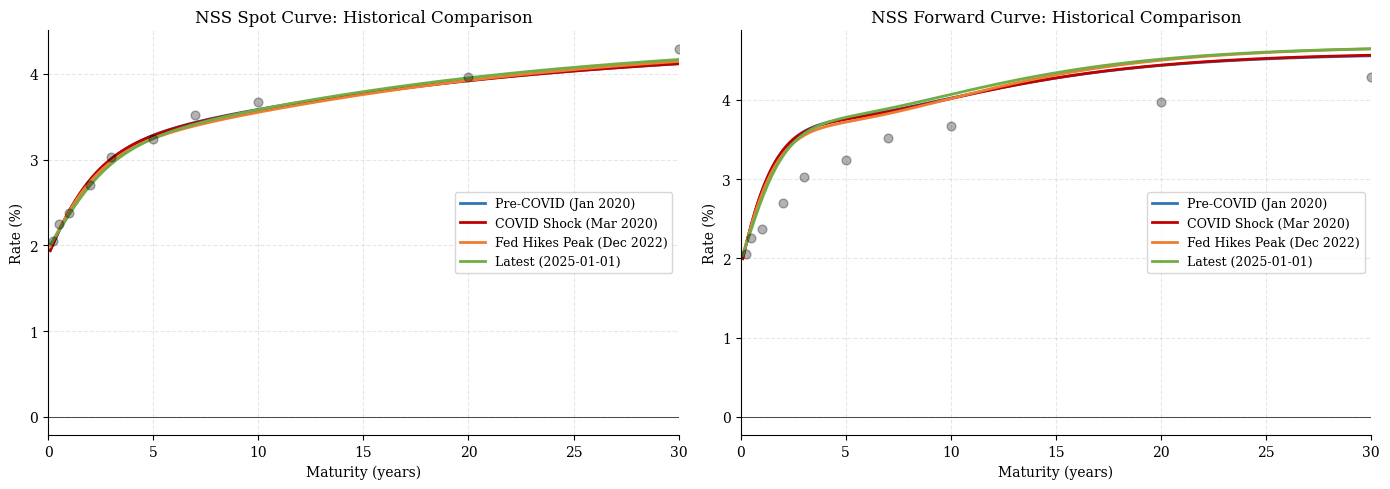

In [7]:
# Compare forward curves at three key dates
key_dates = {
    "Pre-COVID (Jan 2020)":    "2020-01-02",
    "COVID Shock (Mar 2020)":  "2020-03-20",
    "Fed Hikes Peak (Dec 2022)": "2022-12-30",
    f"Latest ({df_yields.index[-1].date()})": None
}

t_grid = np.linspace(0.1, 30, 300)
colors = ["#2E75B6", "#C00000", "#ED7D31", "#70AD47"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (label, date_str), color in zip(
        key_dates.items(), colors):

    if date_str is None:
        idx = -1
    else:
        idx = df_yields.index.get_indexer(
            [date_str], method="nearest")[0]

    y_i      = df_yields.iloc[idx].values
    c_i      = Bootstrapper.from_yields(maturities, y_i)
    interp_i = CurveInterpolator(c_i)
    beta_i   = interp_i.fit_nss()

    r_spot    = CurveInterpolator.nss_spot(t_grid, beta_i)
    r_forward = CurveInterpolator.nss_forward(t_grid, beta_i)

    axes[0].plot(t_grid, r_spot    * 100,
                 color=color, lw=2, label=label)
    axes[1].plot(t_grid, r_forward * 100,
                 color=color, lw=2, label=label)

for ax, title in zip(axes, ["Spot Curve",
                              "Forward Curve"]):
    ax.scatter(maturities,
               df_yields.iloc[-1].values * 100,
               color="black", zorder=5, s=40, alpha=0.3)
    ax.set_xlim(0, 30)
    ax.set_xlabel("Maturity (years)")
    ax.set_ylabel("Rate (%)")
    ax.set_title(f"NSS {title}: Historical Comparison")
    ax.legend(fontsize=9)
    ax.axhline(0, color="black", lw=0.5)

plt.tight_layout()
plt.savefig("../figures/02_historical_curves.png", dpi=150)
plt.show()

---
## Key Observations

1. **Linear interpolation** produces discontinuous forward
   rates — visible as sharp kinks at every tenor node.
   Never used in production systems like MX.3.

2. **Cubic spline** produces smooth forwards but can
   oscillate between nodes (Runge's phenomenon) especially
   at the short end.

3. **NSS** produces economically sensible curves with
   clear interpretation of each parameter. This is the
   standard in central banks and institutional systems.

4. **Yield curve inversion** (Dec 2022): short rates
   above long rates — the forward curve shows the market
   expected the Fed to eventually cut rates.

5. **β₁ (slope)** is the most informative parameter:
   - β₁ < 0: normal upward sloping curve
   - β₁ > 0: inverted curve
   - β₁ ≈ 0: flat curve